# Import Libraries

In [1]:
# Import warnings to keep the notebook output clean
import warnings
warnings.filterwarnings('ignore')

# Import Libraries
# %matplotlib inline ensures that plots are displayed within the notebook
%matplotlib inline 
import matplotlib.pyplot as plt # To create visualizations.
import seaborn as sns # For statistical data visualizations.
import pandas as pd # For data manipulation and analysis.
import numpy as np # For numerical computations.

# Load Dataset

In [2]:
# load/Read the dataset
df = pd.read_excel(r"C:\Users\ifech\Downloads\Public_Transport_Trips_EDA.xlsx")

# Initial Data Exploration

In [3]:
# Check the first few rows of the dataset.
# Understand the data structure, column names and the values.

df.head()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
0,TRIP0001,FERRY,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,NaN,F
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,NaN,F
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday,NaN,F
3,TRIP0004,FERRY,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,NaN,2024-01-01,Sunday,NaN,F
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,NaN,NaN,2024-01-01,Monday,NaN,F


In [4]:
"""
Check the last few rows of the dataset
This will help to spot any irregularities or missing values at the end of the dataset.
"""

df.tail()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
995,TRIP0996,train,North Station,West End,2024-01-01 22:35:00,NaN,40.546670,51.0,2024-02-11,Saturday,NaN,NaN
996,TRIP0997,Bus,Central,West End,2024-01-01 22:36:00,63.0,7.772635,35.0,2024-02-11,Thursday,NaN,NaN
997,TRIP0998,FERRY,West End,North Station,2024-01-01 22:37:00,23.0,NaN,8.0,2024-02-11,Saturday,NaN,NaN
998,TRIP0999,Tram,South Point,Central,2024-01-01 22:38:00,9.0,43.300617,169.0,2024-02-11,Sunday,NaN,NaN
999,TRIP1000,train,Airport,West End,2024-01-01 22:39:00,34.0,8.168803,21.0,2024-02-11,Tuesday,NaN,NaN


In [5]:
"""
Check the Data Shape
This will give a detailed information about the number of rows and columns.
"""

df.shape

(1000, 12)

In [6]:
# Check the basic information about the dataset.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Trip_ID                1000 non-null   object        
 1   Mode_of_Transport      1000 non-null   object        
 2   Departure_Station      1000 non-null   object        
 3   Arrival_Station        1000 non-null   object        
 4   Departure_Time         1000 non-null   datetime64[ns]
 5   Passenger_Count        900 non-null    float64       
 6   Fare_Amount            900 non-null    float64       
 7   Trip_Duration_Minutes  900 non-null    float64       
 8   Trip_Date              1000 non-null   datetime64[ns]
 9   Day_of_Week            1000 non-null   object        
 10  Unnamed: 10            0 non-null      float64       
 11  Unnamed: 11            299 non-null    object        
dtypes: datetime64[ns](2), float64(4), object(6)
memory usage: 93.9+

# Data Cleaning

In [7]:
"""
Check Duplicate Values in the dataset.
This will help to prevent bias in our analysis and model training.
"""

print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [8]:
"""
Check for missing values in the dataset
This will help us identify columns with incomplete data that may need cleaning.
"""

print("Missing Values Before Cleaning:")
print(df.isnull().sum())

Missing Values Before Cleaning:
Trip_ID                     0
Mode_of_Transport           0
Departure_Station           0
Arrival_Station             0
Departure_Time              0
Passenger_Count           100
Fare_Amount               100
Trip_Duration_Minutes     100
Trip_Date                   0
Day_of_Week                 0
Unnamed: 10              1000
Unnamed: 11               701
dtype: int64


In [9]:
# Drop empty/irrelevant columns with large missing values
df = df.drop(["Unnamed: 10", "Unnamed: 11"], axis=1)
df.head()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week
0,TRIP0001,FERRY,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday
3,TRIP0004,FERRY,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,NaN,2024-01-01,Sunday
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,NaN,NaN,2024-01-01,Monday


In [10]:
#fill the missing values in the selected numerical columns with the mean.

for i in ['Passenger_Count', 'Fare_Amount', 'Trip_Duration_Minutes']:
    df[i] = df[i].fillna(df[i].mean())

In [11]:
# Display the missing values after cleaning data
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
Trip_ID                  0
Mode_of_Transport        0
Departure_Station        0
Arrival_Station          0
Departure_Time           0
Passenger_Count          0
Fare_Amount              0
Trip_Duration_Minutes    0
Trip_Date                0
Day_of_Week              0
dtype: int64


In [12]:
# Clean categorical variables
df['Mode_of_Transport'] = (df['Mode_of_Transport'].str.strip().str.lower().str.title())
df['Departure_Station'] = (df['Departure_Station'].str.strip().str.lower().str.title())
df['Arrival_Station'] = (df['Arrival_Station'].str.strip().str.lower().str.title())
df['Day_of_Week'] = (df['Day_of_Week'].str.strip().str.lower().str.title())

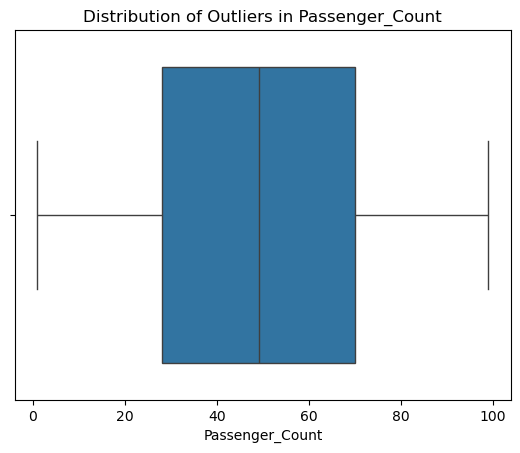

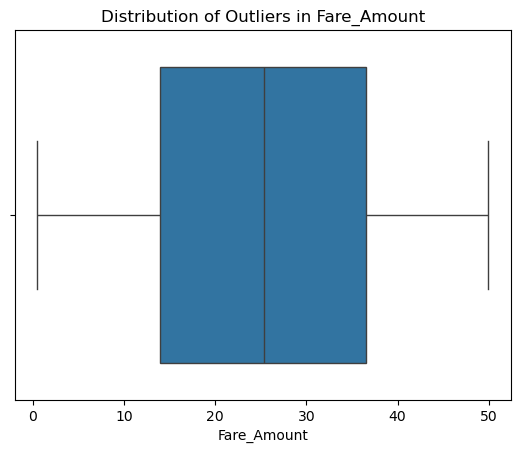

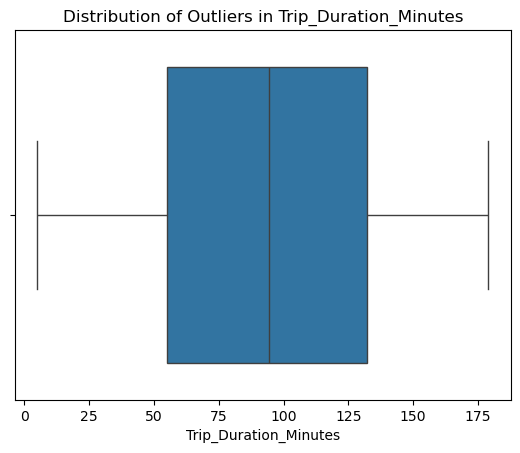

In [13]:
# Identify the Outliers Using Boxplots

for i in df.select_dtypes(include="number").columns:
    sns.boxplot(data=df, x=i)
    plt.title(f'Distribution of Outliers in {i}')
    plt.xlabel(i)
    plt.show()

# Feature Engineering

In [14]:
# Extract time-based features
df['Hour'] = df['Departure_Time'].dt.hour

# Peak period classification
def classify_peak(hour):
    if 6 <= hour <= 10:
        return "Morning Peak"
    elif 16 <= hour <= 20:
        return "Evening Peak"
    else:
        return "Off-Peak"

df['Peak_Period'] = df['Hour'].apply(classify_peak)

# Descriptive Statistics

In [15]:
"""
Check the Descriptive Statistics of the dataset.
This will provide a summary statistics for the numerical columns.
Transpose will also help to easily read the statistics as rows and columns.
Discovered there are NAN values in the time/date variables because pandas cannot calculate standard deviation for time/date variables.
"""
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Departure_Time,1000,2024-01-01 14:19:30,2024-01-01 06:00:00,2024-01-01 10:09:45,2024-01-01 14:19:30,2024-01-01 18:29:15,2024-01-01 22:39:00,NaN
Passenger_Count,1000.0,49.154444,1.0,28.0,49.154444,70.0,99.0,26.275424
Fare_Amount,1000.0,25.360742,0.500576,13.917364,25.360742,36.580122,49.945184,13.72152
Trip_Duration_Minutes,1000.0,94.27,5.0,55.0,94.27,132.25,179.0,48.033891
Trip_Date,1000,2024-01-21 08:03:50.400000,2024-01-01 00:00:00,2024-01-11 00:00:00,2024-01-21 00:00:00,2024-02-01 00:00:00,2024-02-11 00:00:00,NaN
Hour,1000.0,13.84,6.0,10.0,14.0,18.0,22.0,4.816388


In [16]:
# Perform descriptive statistics on the categorical data columns.

df.describe(include="object")

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Day_of_Week,Peak_Period
count,1000,1000,1000,1000,1000,1000
unique,1000,4,6,6,7,3
top,TRIP1000,Bus,Central,Airport,Sunday,Off-Peak
freq,1,332,208,213,167,400


# Univariate/Bivariate/Multivariate Analysis

## Univariate Analysis

### Frequency count for categorical variables

#### Transport Mode Distribution

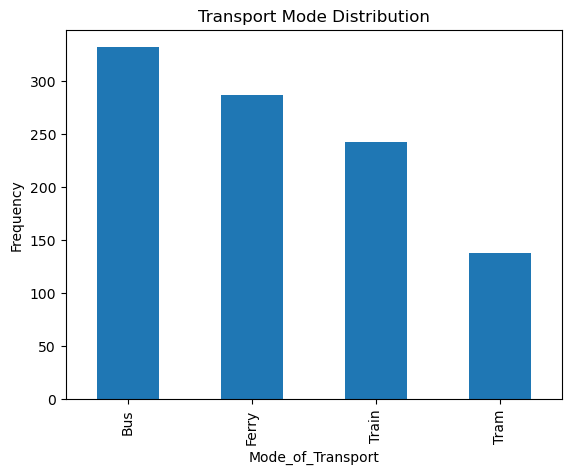

In [17]:
df['Mode_of_Transport'].value_counts().plot(kind='bar')
plt.ylabel("Frequency")
plt.title("Transport Mode Distribution")
plt.show()

#### Station Demand Analysis

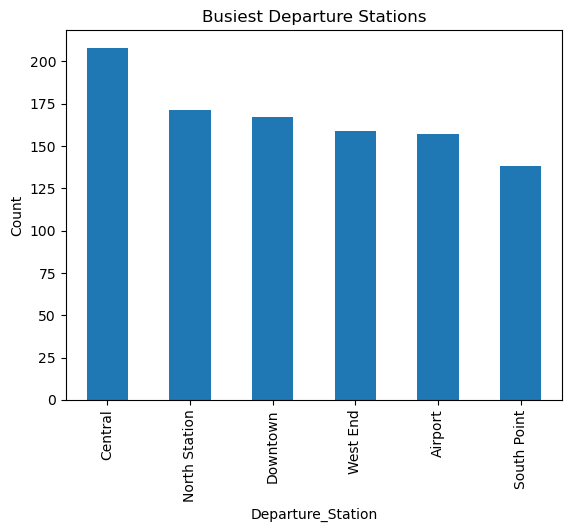

In [18]:
# Plot barchart for the Departure_Station Column
df['Departure_Station'].value_counts().plot(kind='bar')
plt.title("Busiest Departure Stations")
plt.xlabel("Departure_Station")
plt.ylabel("Count")
plt.show()

#### Arrival Station Distribution

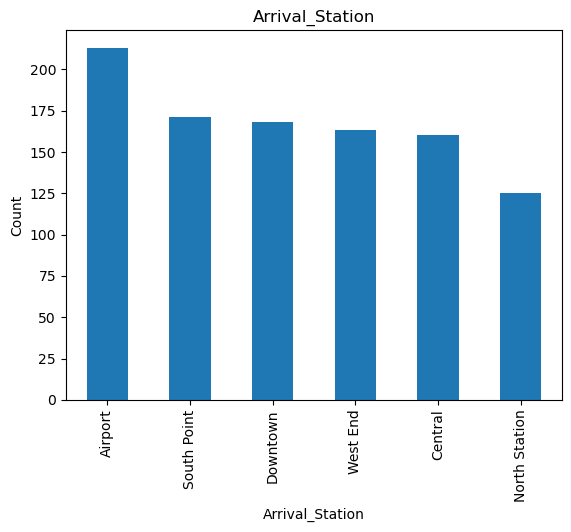

In [19]:
# Plot barchart for the Arrival_Station Column
df['Arrival_Station'].value_counts().plot(kind='bar')
plt.title("Arrival_Station")
plt.xlabel("Arrival_Station")
plt.ylabel("Count")
plt.show()

#### Trips by Day

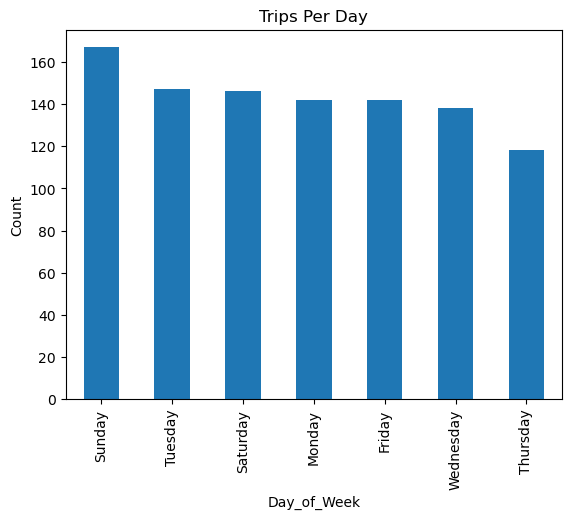

In [20]:
# Plot barchart for the Day_of_Week Column
df['Day_of_Week'].value_counts().plot(kind='bar')
plt.title("Trips Per Day")
plt.xlabel("Day_of_Week")
plt.ylabel("Count")
plt.show()

#### Passenger Distribution

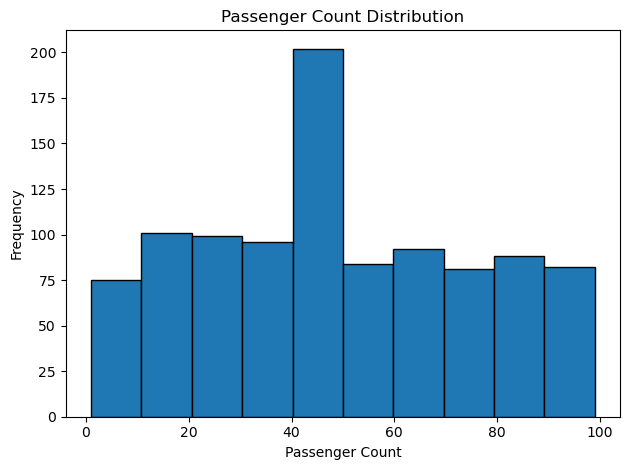

In [21]:
# Plot histogram for the Passenger_Count Column
plt.hist(df['Passenger_Count'], edgecolor='black')
plt.title("Passenger Count Distribution")
plt.xlabel("Passenger Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### Fare Count

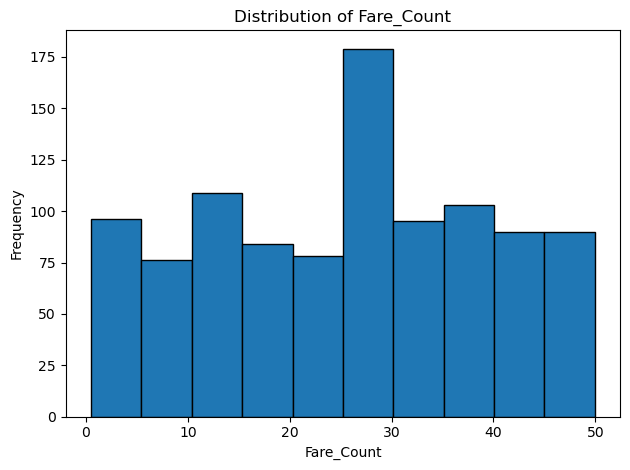

In [22]:
# Plot histogram for the Fare_Count Column
plt.hist(df['Fare_Amount'], edgecolor='black')
plt.title("Distribution of Fare_Count")
plt.xlabel("Fare_Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### Transport Performance Analysis

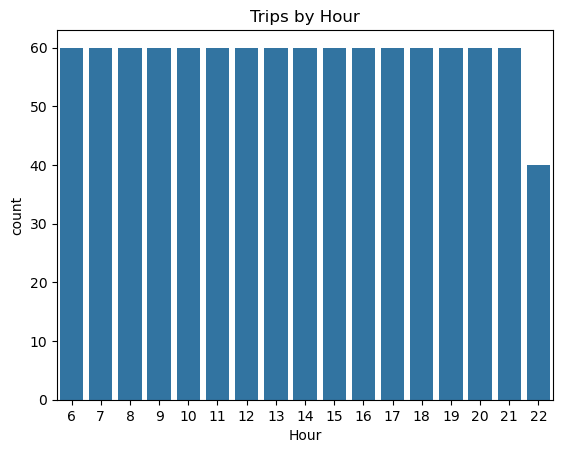

In [23]:
sns.countplot(x='Hour', data=df)
plt.title("Trips by Hour")
plt.show()

#### Trips by Peak Period

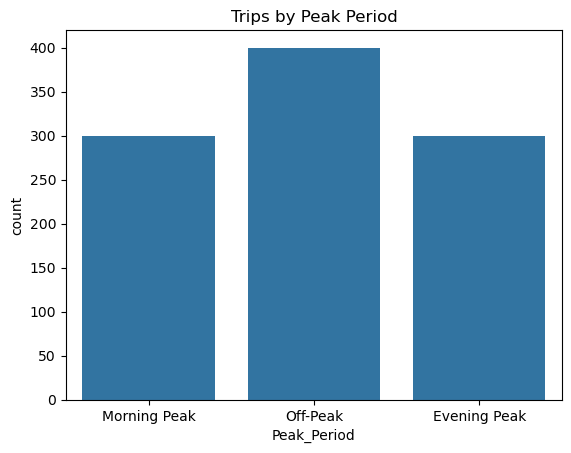

In [24]:
sns.countplot(x='Peak_Period', data=df)
plt.title("Trips by Peak Period")
plt.show()

## Bivariate Analysis

#### Passenger Count by Mode of Transportation

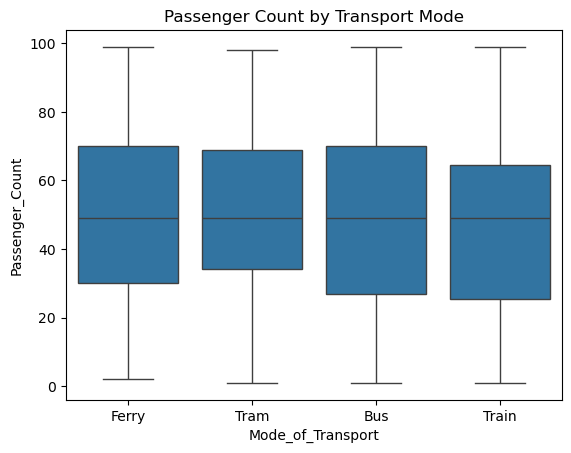

In [25]:
sns.boxplot(x='Mode_of_Transport', y='Passenger_Count', data=df)
plt.title("Passenger Count by Transport Mode")
plt.show()

#### Fare vs Duration

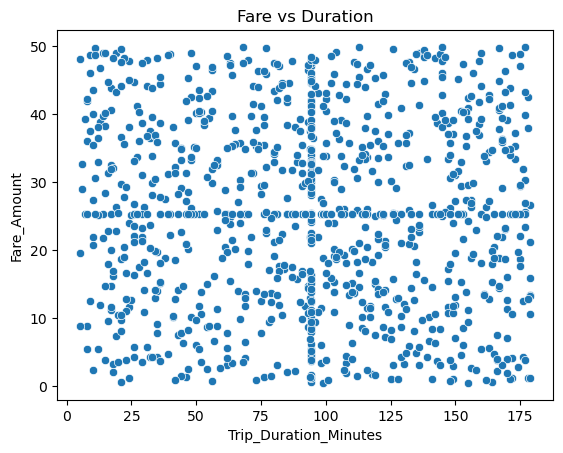

In [26]:
sns.scatterplot(x='Trip_Duration_Minutes', y='Fare_Amount', data=df)
plt.title("Fare vs Duration")
plt.show()

#### Peak Period Usage by Transport Mode

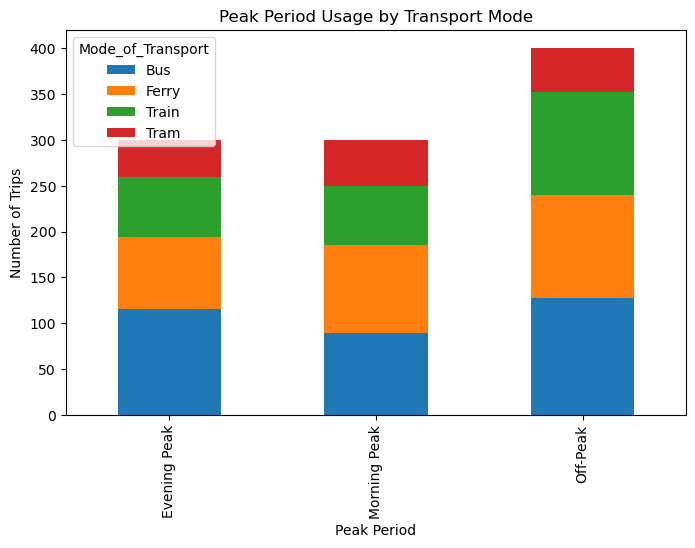

In [27]:
peak_mode = df.groupby(['Peak_Period', 'Mode_of_Transport']).size().unstack()

peak_mode.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title("Peak Period Usage by Transport Mode")
plt.xlabel("Peak Period")
plt.ylabel("Number of Trips")

plt.show()

#### Fare Distribution by Transport Mode

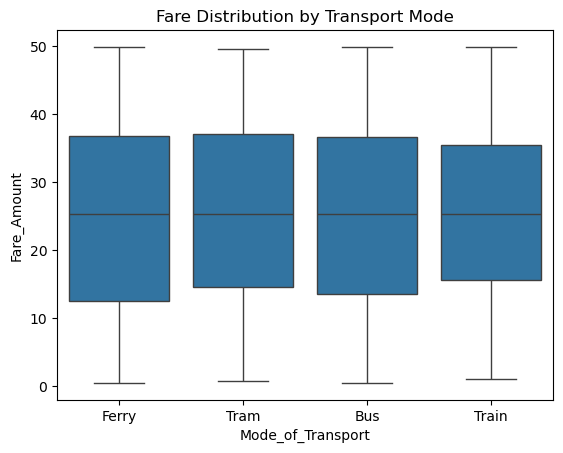

In [28]:
sns.boxplot(
    x='Mode_of_Transport',
    y='Fare_Amount',
    data=df
)

plt.title("Fare Distribution by Transport Mode")
plt.show()

## Multivariate Analysis

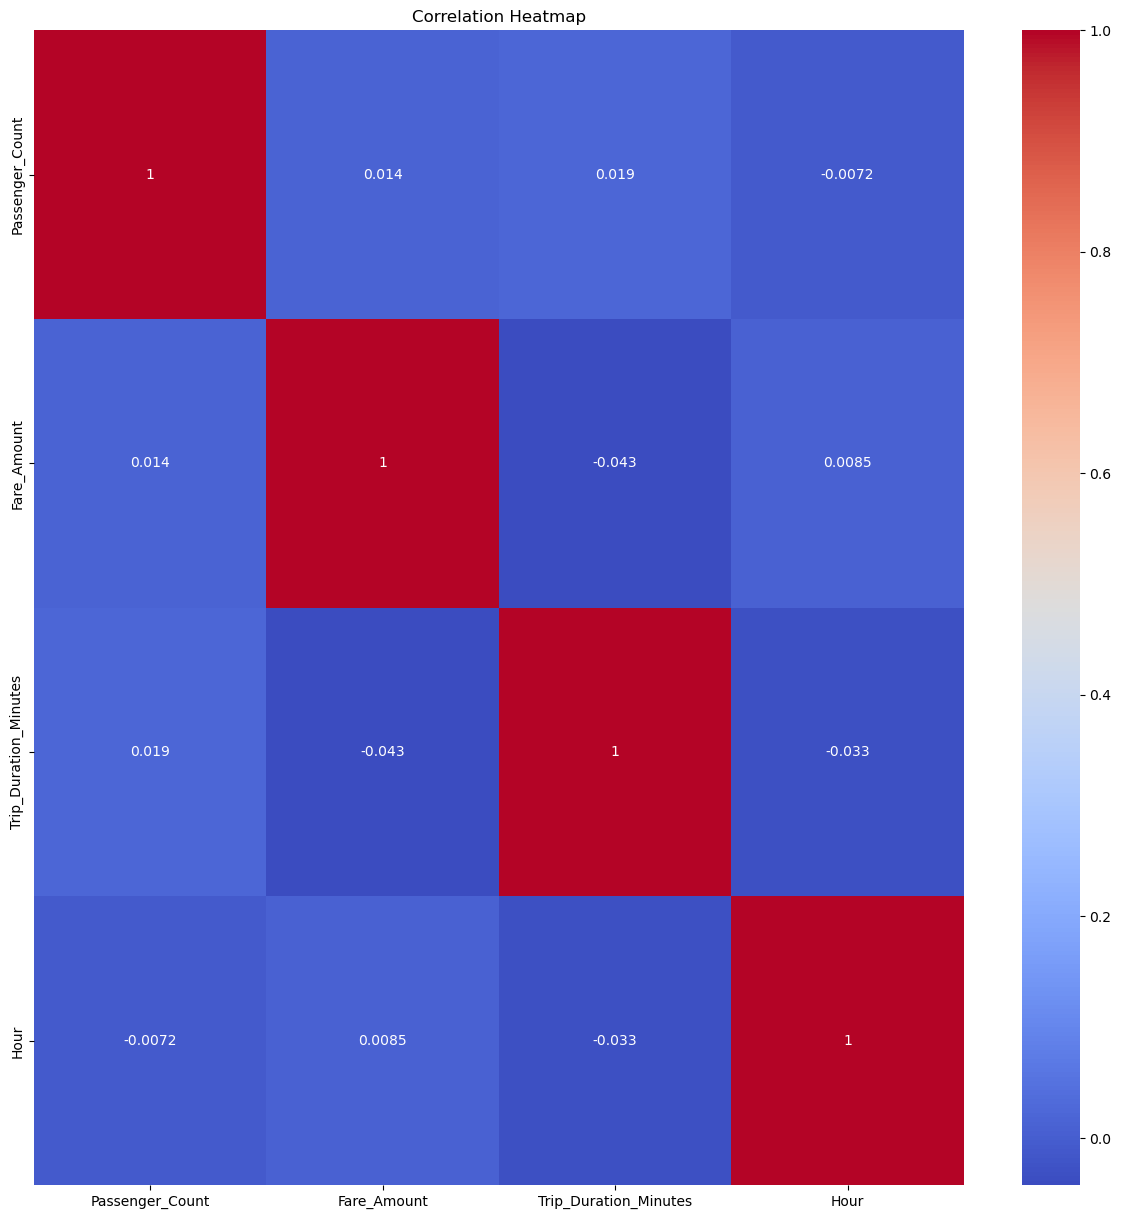

In [29]:
# Understand the correlations between the numerial variables. 
# This will help to effectively interpret the relationship, multicolliniarity and prevent it from affecting our models.

#elect only the numerical columns.
c=df.select_dtypes(include="number").corr()

# Set the figure size for better readability
plt.figure(figsize=(15,15))

# Plot a heatmap to visualize correlations between the numerical variables.
sns.heatmap(c, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap') # Add a title to the map.

plt.show() # Display the correlation heatmap

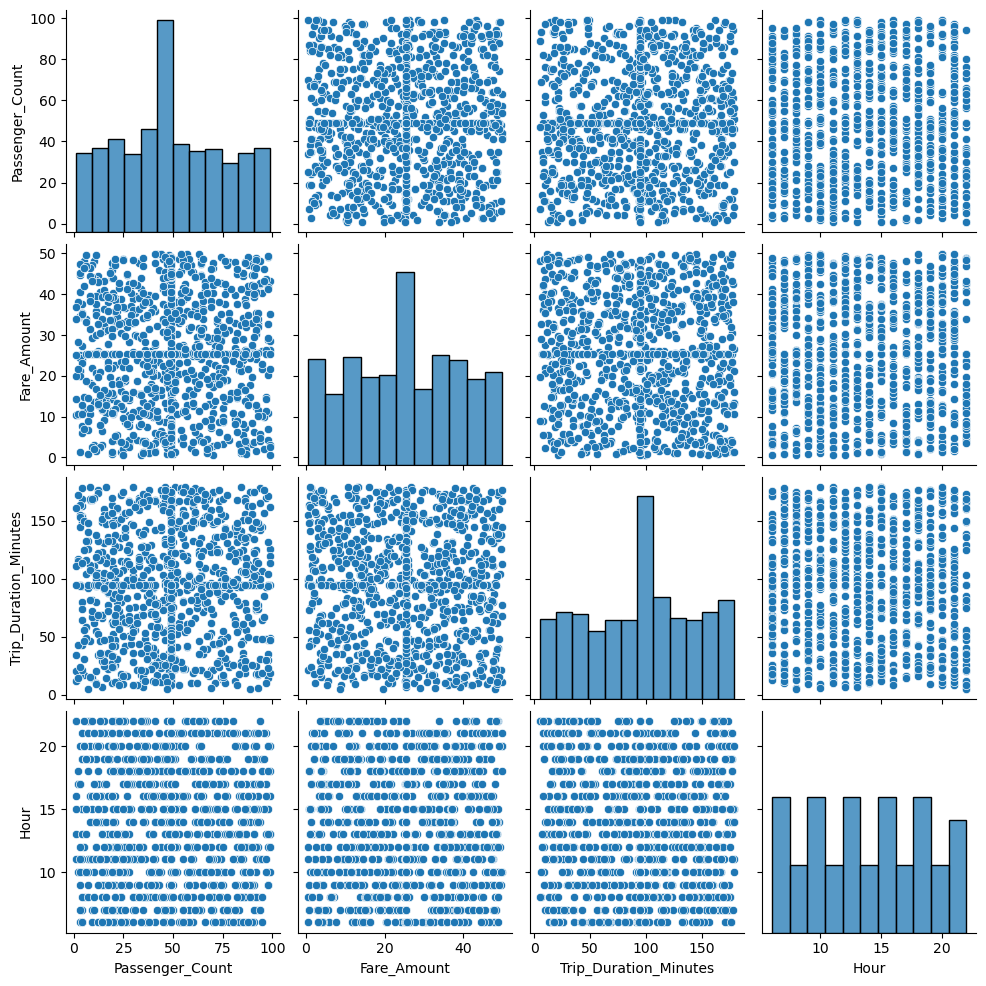

In [30]:
sns.pairplot(df)
plt.show()